Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

import joblib, pickle
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


Load Dataset

In [ ]:
DATA_PATH = "/content/sample_data/crop_dataset.csv"
data = pd.read_csv(DATA_PATH)

print("✅ Dataset Loaded Successfully!")
print("Dataset Shape:", data.shape)
display(data.head())


✅ Dataset Loaded Successfully!
Dataset Shape: (6000, 12)


,District,Month,Soil_Type,N,P,K,pH,Temperature_C,Humidity_%,Rainfall_mm,Sunlight_lux,Recommended_Crop
0,Solapur,April,Black,94,50,47,6.60,26,58,73,31685,Tomato
1,Solapur,February,Red,117,41,40,6.30,25,83,98,55658,Tomato
2,Solapur,October,Loamy,82,44,58,6.68,28,78,67,40627,Tomato
3,Solapur,December,Red,88,41,59,6.24,26,83,57,44541,Tomato
4,Solapur,April,Red,119,43,41,6.43,25,81,53,39692,Tomato


Encode Categorical Features

In [ ]:
district_encoder = LabelEncoder()
month_encoder = LabelEncoder()
soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

data["District"] = district_encoder.fit_transform(data["District"])
data["Month"] = month_encoder.fit_transform(data["Month"])
data["Soil_Type"] = soil_encoder.fit_transform(data["Soil_Type"])
data["Recommended_Crop"] = crop_encoder.fit_transform(data["Recommended_Crop"])

crop_dict = dict(enumerate(crop_encoder.classes_))
district_rev = dict(zip(district_encoder.classes_, district_encoder.transform(district_encoder.classes_)))
month_rev = dict(zip(month_encoder.classes_, month_encoder.transform(month_encoder.classes_)))
soil_rev = dict(zip(soil_encoder.classes_, soil_encoder.transform(soil_encoder.classes_)))


Feature & Target Selection

In [ ]:
X = data.drop("Recommended_Crop", axis=1)
y = data["Recommended_Crop"]

print("📊 Class Distribution:")
print(Counter(y))


📊 Class Distribution:
Counter({8: 600, 1: 600, 2: 600, 7: 600, 3: 600, 4: 600, 6: 600, 9: 600, 0: 600, 5: 600})


Train / Validation / Test Split (70-20-10)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

print("✅ Dataset Split Completed!")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Validation Samples: {X_val.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")


✅ Dataset Split Completed!
Training Samples: 4200
Validation Samples: 1200
Test Samples: 600


Data Preprocessing Pipeline

In [ ]:
numeric_features = [
    "N", "P", "K", "pH",
    "Temperature_C", "Humidity_%",
    "Rainfall_mm", "Sunlight_lux"
]

categorical_features = ["District", "Month", "Soil_Type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_features)
    ]
)


XGBoost Model

In [ ]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    learning_rate=0.05,
    n_estimators=200,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.5,
    min_child_weight=5
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_model)
])


Train the Model

In [ ]:
pipeline.fit(X_train, y_train)
print("✅ Model Training Completed!")


✅ Model Training Completed!


Model Evaluation

Training Accuracy: 79.07%
Validation Accuracy: 68.08%
Test Accuracy: 69.33%


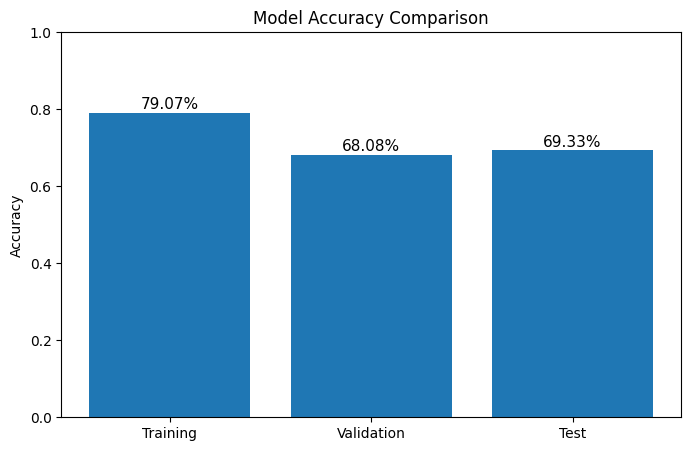

In [ ]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
val_acc = accuracy_score(y_val, pipeline.predict(X_val))
test_acc = accuracy_score(y_test, pipeline.predict(X_test))

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")


accuracy_labels = ["Training", "Validation", "Test"]
accuracy_values = [train_acc, val_acc, test_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(accuracy_labels, accuracy_values)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar, acc in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc*100:.2f}%",
        ha="center",
        fontsize=11
    )

plt.show()



Classification Report

In [ ]:
print(classification_report(
    y_test,
    pipeline.predict(X_test),
    target_names=crop_encoder.classes_
))


              precision    recall  f1-score   support

Bottle Gourd       0.82      0.62      0.70        60
     Brinjal       0.73      0.63      0.68        60
      Chilli       0.82      0.67      0.73        60
   Coriander       0.43      0.43      0.43        60
   Fenugreek       0.59      0.85      0.69        60
  Lemongrass       0.91      0.85      0.88        60
        Mint       0.64      0.92      0.75        60
     Spinach       0.64      0.45      0.53        60
      Tomato       0.73      0.85      0.78        60
       Tulsi       0.77      0.67      0.71        60

    accuracy                           0.69       600
   macro avg       0.71      0.69      0.69       600
weighted avg       0.71      0.69      0.69       600



Sample Predictions

In [ ]:
X_test_df = X_test.copy()
X_test_df["Actual_Crop"] = [crop_dict[i] for i in y_test]

y_pred_test = pipeline.predict(X_test)
X_test_df["Predicted_Crop"] = [crop_dict[i] for i in y_pred_test]

X_test_df["District"] = district_encoder.inverse_transform(X_test_df["District"])
X_test_df["Month"] = month_encoder.inverse_transform(X_test_df["Month"])
X_test_df["Soil_Type"] = soil_encoder.inverse_transform(X_test_df["Soil_Type"])

top3_preds = []
for i in range(len(X_test)):
    probs = pipeline.predict_proba(X_test.iloc[[i]])[0]
    top3 = np.argsort(probs)[-3:][::-1]
    top3_preds.append(", ".join([crop_dict[j] for j in top3]))

X_test_df["Top_3_Crops"] = top3_preds
display(X_test_df.head(10))


,District,Month,Soil_Type,N,P,K,pH,Temperature_C,Humidity_%,Rainfall_mm,Sunlight_lux,Actual_Crop,Predicted_Crop,Top_3_Crops
211,Solapur,December,Black,102,44,47,6.04,28,62,92,66224,Tomato,Brinjal,"Brinjal, Tomato, Bottle Gourd"
1463,Solapur,May,Red,77,30,43,6.54,22,54,73,53843,Chilli,Mint,"Mint, Chilli, Bottle Gourd"
2859,Sangli,December,Black,40,20,35,6.60,20,45,58,63148,Coriander,Coriander,"Coriander, Fenugreek, Spinach"
1617,Solapur,February,Red,88,34,46,5.61,21,81,49,34858,Chilli,Chilli,"Chilli, Brinjal, Tomato"
3808,Sangli,February,Black,62,33,38,6.72,25,82,43,46552,Mint,Mint,"Mint, Tulsi, Chilli"
2669,Sangli,March,Black,40,23,39,6.89,18,62,64,37529,Coriander,Coriander,"Coriander, Spinach, Fenugreek"
1008,Solapur,February,Red,103,44,45,5.84,24,78,47,40482,Brinjal,Brinjal,"Brinjal, Chilli, Tomato"
2280,Solapur,March,Loamy,42,39,21,6.79,15,49,46,37965,Spinach,Fenugreek,"Fenugreek, Spinach, Coriander"
1004,Sangli,November,Loamy,95,35,50,6.72,29,46,73,59492,Brinjal,Brinjal,"Brinjal, Chilli, Bottle Gourd"
4444,Sangli,June,Red,67,32,24,6.05,23,63,56,67772,Tulsi,Spinach,"Spinach, Tulsi, Chilli"


Confusion Matrix

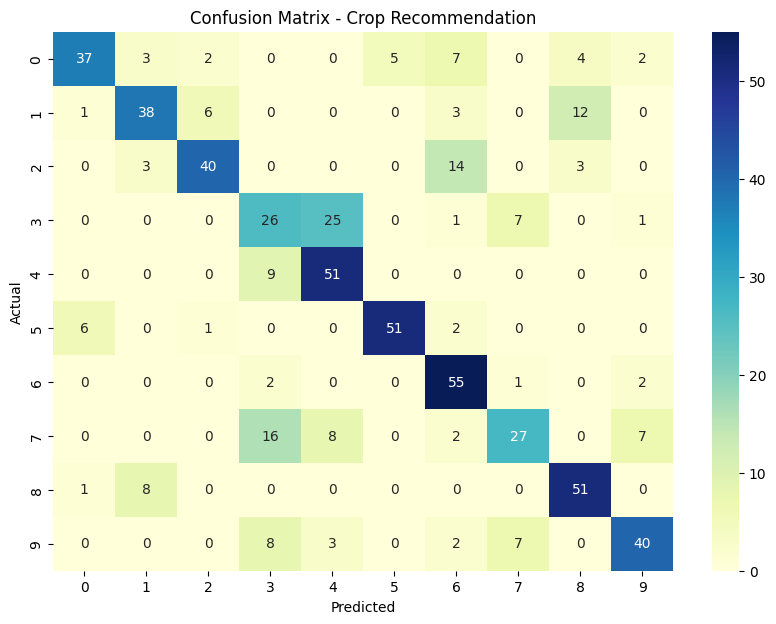

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(
    confusion_matrix(y_test, pipeline.predict(X_test)),
    annot=True, fmt="d", cmap="YlGnBu"
)
plt.title("Confusion Matrix - Crop Recommendation")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Interactive Recommendation System

In [ ]:
district_widget = widgets.Dropdown(options=district_rev.keys(), description="District:")
month_widget = widgets.Dropdown(options=month_rev.keys(), description="Month:")
soil_widget = widgets.Dropdown(options=soil_rev.keys(), description="Soil:")

N_input = widgets.FloatText(70, description="N")
P_input = widgets.FloatText(40, description="P")
K_input = widgets.FloatText(40, description="K")
ph_input = widgets.FloatText(6.5, description="pH")

temp_input = widgets.FloatText(25, description="Temp")
humidity_input = widgets.FloatText(70, description="Humidity")
rainfall_input = widgets.FloatText(100, description="Rainfall")
sunlight_input = widgets.FloatText(40000, description="Sunlight")

predict_button = widgets.Button(description="Recommend Crop", button_style="success")
output = widgets.Output()

def recommend_crop(b):
    with output:
        clear_output()

        user_df = pd.DataFrame([{
            "District": district_rev[district_widget.value],
            "Month": month_rev[month_widget.value],
            "Soil_Type": soil_rev[soil_widget.value],
            "N": N_input.value,
            "P": P_input.value,
            "K": K_input.value,
            "pH": ph_input.value,
            "Temperature_C": temp_input.value,
            "Humidity_%": humidity_input.value,
            "Rainfall_mm": rainfall_input.value,
            "Sunlight_lux": sunlight_input.value
        }])

        probs = pipeline.predict_proba(user_df)[0]
        top3 = np.argsort(probs)[-3:][::-1]

        print("🌾 Top 3 Recommended Crops:")
        for idx in top3:
            # print(f"- {crop_dict[idx]} ({probs[idx]*100:.1f}%)")
            print(f"- {crop_dict[idx]}")

predict_button.on_click(recommend_crop)

display(
    district_widget, month_widget, soil_widget,
    N_input, P_input, K_input, ph_input,
    temp_input, humidity_input, rainfall_input, sunlight_input,
    predict_button, output
)

Dropdown(description='District:', options=('Sangli', 'Solapur'), value='Sangli')

Dropdown(description='Month:', options=('April', 'August', 'December', 'February', 'January', 'July', 'June', …

Dropdown(description='Soil:', options=('Black', 'Loamy', 'Red'), value='Black')

FloatText(value=70.0, description='N')

FloatText(value=40.0, description='P')

...

FloatText(value=70.0, description='Humidity')

FloatText(value=100.0, description='Rainfall')

FloatText(value=40000.0, description='Sunlight')

Button(button_style='success', description='Recommend Crop', style=ButtonStyle())

Output()

Save Model & Encoders

In [ ]:
joblib.dump(pipeline, "crop_xgb_pipeline.pkl")
pickle.dump(crop_encoder, open("crop_encoder.pkl", "wb"))
pickle.dump(crop_dict, open("crop_dict.pkl", "wb"))
pickle.dump(district_encoder, open("district_encoder.pkl", "wb"))
pickle.dump(month_encoder, open("month_encoder.pkl", "wb"))
pickle.dump(soil_encoder, open("soil_encoder.pkl", "wb"))

print("💾 Model and Encoders Saved Successfully!")


💾 Model and Encoders Saved Successfully!
